# **FORWARD MODEL OF VEHICLE LATERAL DYNAMICS**

This notebook presents the Model-Structured Neural Network model of a vehicle lateral dynamics. The dataset used to train the network was collected in CarMaker14 using a 14 Dof vehicle model, the Kia_EV6_demo, an electric car. The training and validation set were collected on a custom track with a spread range of cruvature values and different corner types, from constant radius corner to clothoids. Three different driver profiles were adopted in order to cover a larger values of accelerations, "normal", "aggressive" and "prudent" respectively. Every dataset was then mirrored in order to avoid offsets in the training, assuming that the vehicle can be approximated to be reasonably symmetric in right and left corners.
Finally, the test telemetries were collected on a different track to proove the robustness of the trained network.

## Initialization

In [1]:
# Import necessary packages
import sys, os
import pandas as pd

# import nnodely modules
from nnodely import *
from nnodely.support.utils import *
from nnodely.support import earlystopping
from nnodely.support.earlystopping import select_best_model

# import a library for plots
import matplotlib as mpl

mpl.rcParams.update(mpl.rcParamsDefault)
import matplotlib.pyplot as plt

plt.close("all")
SMALL_SIZE = 14
MEDIUM_SIZE = 22
BIGGER_SIZE = 26
plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=MEDIUM_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=SMALL_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rc("grid", linestyle="--", color="grey")

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>-- nnodely_v1.5.4 --<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<


In [2]:
# Configurations
path_folder = "trained_models"  # folder to save the model
lat_dyna_model = nnodely(
    visualizer=MPLNotebookVisualizer(), seed=1, workspace=path_folder, log_internal=True
)

# MS-NN model

The structure of the Model-Structured Neural Network is derived from the description of the lateral dynamic performance of the vehicles through the understeering gradient that describe the correction to be applied with respect to the kinematic (or Ackermann) steering. In particular, denoting with $\delta$ the steering angle at wheels (note that $\delta = \delta_{sw}/\tau_{sw}$, where $\delta_{sw}$ is the steering wheel angle and $\tau_{sw}$ is the steering ratio), the relationship between steer angle and curvature $\kappa$ is:
$$
\kappa = \frac{\delta}{1+A v_x^2}
$$
where the parameter $A$ is generally called "understeering gradient". 

The **local_input_model** is a *LoacalModel* composed of *FIR filters* activated by *Fuzzy triangular memebership functions* on forward speed takes into account the dynamic response of the system that is function of the speed.  
The **local_osus_corr** is another *LocalModel* that implements the algebraic relation above as function of the learnable parameter **A** that varies as function of the longitudinal acceleration.  
Hence, the output curvature is the product of the two local models outputs.

![](figs/fig_model.png)

In [3]:
# ----------------------------------------------------------------
# Inputs
# ----------------------------------------------------------------
vx_in = Input("model_vx_in")  # [m/s] longitudinal velocity
steer_in = Input("model_steer_in")  # [rad] steering wheel angle
ax_in = Input("model_ax_in")  # [m/s^2] lateral acceleration

# ----------------------------------------------------------------
# Hyperparameters
# ----------------------------------------------------------------
samples_past_steer = (
    30  # number of samples in the past for the steering wheel angle prediction
)
n_channels_vx = 8  # number of channels for activation function vx
chan_vx = list(np.linspace(8, 23, num=n_channels_vx))  # centers of the channels vx
chan_ax = [-2, -1, 0.0, 1.0, 2.0]  # centers of the channels ax

# Exponential weights for normalisation of FIR parameters during training
W_fir = np.array(
    [
        [np.exp(-((i / (samples_past_steer / 2)) ** 2))]
        for i in range(-samples_past_steer + 1, 1)
    ]
)
W_constant = Constant("W_fir", sw=30, values=W_fir)


# ----------------------------------------------------------------
# Understeer correction function
# ----------------------------------------------------------------
def understeer_corr_local(
    vx,  # input
    A,  # learnable parameter
):
    return 1 / (1 + A * torch.pow(vx, 2))


understeer_corr = ParamFun(understeer_corr_local)

# ----------------------------------------------------------------
# Local models
# ----------------------------------------------------------------
# Activation functions
fuzzy_vx = Fuzzify(centers=chan_vx, functions="Triangular")(vx_in.last())
fuzzy_ax = Fuzzify(centers=chan_ax, functions="Triangular")(ax_in.last())


# FIR input functions
def Input_Function_Gen(idx):
    def fir_out(fir_input):
        out = Fir(
            W_init="init_constant", W_init_params={"value": 1}, W=f"Fir_{idx[0]}"
        )(fir_input)
        return out

    return fir_out


# Local Input Model
local_input_model = LocalModel(pass_indexes=True, input_function=Input_Function_Gen)
out_input_model = local_input_model(
    (steer_in.sw(samples_past_steer) * W_constant), fuzzy_vx
)


# Parametric functions: Understeer correction
def Understeer_Function_Gen(idx):
    def osus_out(vx_input):
        A = Parameter("A_" + str(idx[0]), values=[[1e-5]])
        return understeer_corr(vx_input, A)

    return osus_out


# Local Understeer Correction Model
local_osus_corr = LocalModel(pass_indexes=True, input_function=Understeer_Function_Gen)
out_osus = local_osus_corr(vx_in.last(), fuzzy_ax)

# ----------------------------------------------------------------
# Outputs
# ----------------------------------------------------------------
curv_out = Output("model_curv", out_input_model * out_osus)  # output of the model

# ----------------------------------------------------------------
# Add model
# ----------------------------------------------------------------
lat_dyna_model.addModel("vehicle_model", curv_out)

### Loss functions definitions

Two loss terms are defined, both of them use the MSE as loss function.  
The first loss is evaluated on the curvature error: the next-step curvature predicted by the model is compared to the dataset curvature.  
The second loss is evaluated on the heading error*: both reference heading and predicted heading are evaluated starting form the curvature values. 

*assuming steady-state curvature, the following relation holds: $\psi = \int \kappa v_x \, \mathrm{d}t$, where $\psi$ denotes the heading angle.

The second loss term provided more robustness to the network, reducing possible biases. The dependency to forward speed, moreover, weights the loss term reducing the bias espetially for high speed, where a bias is more determinant in the tracking error of the desired trajectory.

In [4]:
# ------------------------------------------------------------------------
# Targets
# ------------------------------------------------------------------------
curv_in = Input("model_curv_in")  # [1/m] path curvature

# Definition of heading as integral of curvature multiplied by the longitudinal speed
heading_target = Integrate(curv_in.next() * vx_in.next())
heading_nn = Integrate(out_input_model * out_osus * vx_in.next())

# Add a loss function: mean squared error for the curvature prediction
lat_dyna_model.addMinimize("curv_error", curv_in.next(), curv_out, loss_function="mse")
# Add a loss function: mean squared error for the heading prediction
lat_dyna_model.addMinimize("heading_error", heading_target, heading_nn)

### Model neuralization

In [5]:
# Generate the model
lat_dyna_model.neuralizeModel(
    sample_time=0.05
)  # neuralize the model with the chosen sample time

[neuralizeModel] Closed loop on Mul87_int34 with sample in the future.
[neuralizeModel] Closed loop on Mul77_int33 with sample in the future.
================================ nnodely Model =================================
{'Constants': {'SampleTime': {'dim': 1, 'values': 0.05},
               'W_fir': {'dim': 1,
                         'sw': 30,
                         'values': [[0.023806948214769363],
                                    [0.03067079372704029],
                                    [0.039163894951343536],
                                    [0.04956628382205963],
                                    [0.062176525592803955],
                                    [0.07730474323034286],
                                    [0.09526325762271881],
                                    [0.116354800760746],
                                    [0.14085842669010162],
                                    [0.16901332139968872],
                                    [0.20100119709968567],


# Training

The training is done in two steps. The first training has not prediction samples in the future, that corresponds to train the network uniquely on the curvature loss function. In this way the network weights are adjusted. The second step of training is more a refining of the network weigths, including a future time window on which the integral error is evaluated.

In [6]:
# Dataset loading: all the csv files in the folders defined in 'source' are loaded, with the format defined in 'format'
#                  (the order of the columns in the csv files) and skipping the number of lines defined in 'skiplines'
lat_dyna_model.loadData(
    "training_set",
    source="dataset/training",
    format=[
        "",
        "model_ax_in",
        "",
        "model_vx_in",
        "model_curv_in",
        "",
        "",
        "model_steer_in",
        "",
    ],
    skiplines=1,
)
lat_dyna_model.loadData(
    "validation_set",
    source="dataset/validation",
    format=[
        "",
        "model_ax_in",
        "",
        "model_vx_in",
        "model_curv_in",
        "",
        "",
        "model_steer_in",
        "",
    ],
    skiplines=1,
)

============================ nnodely Model Dataset =============================
Dataset Name:                 training_set
Number of files:              4
Total number of samples:      12212
Shape of model_vx_in:         (12212, 2, 1)
Shape of model_ax_in:         (12212, 1, 1)
Shape of model_steer_in:      (12212, 30, 1)
Shape of model_curv_in:       (12212, 1, 1)
============================ nnodely Model Dataset =============================
Dataset Name:                 validation_set
Number of files:              2
Total number of samples:      5616
Shape of model_vx_in:         (5616, 2, 1)
Shape of model_ax_in:         (5616, 1, 1)
Shape of model_steer_in:      (5616, 30, 1)
Shape of model_curv_in:       (5616, 1, 1)


In [7]:
# Default training parameters definition
training_pars = {
    "num_of_epochs": 150,
    "val_batch_size": 64,
    "train_batch_size": 64,
    "lr": 1e-3,
    "train_dataset": "training_set",
    "validation_dataset": "validation_set",
    "optimizer": "Adam",
    "shuffle_data": True,
    "prediction_samples": -1,  # force to do not evaluate the integral
    "select_model": select_best_model,
    "early_stopping": earlystopping.early_stop_patience,
    "early_stopping_params": {"patience": 20, "error": "curv_error"},
}

======================== nnodely Model Train Parameters ========================
models:                       ['vehicle_model']
num of epochs:                150
update per epochs:            190
└>(n_samples-batch_size)/batch_size+1
shuffle data:                 True
early stopping:               early_stop_patience
early stopping params:        {'error': 'curv_error', 'patience': 20}
train dataset:                training_set
	- batch size:                64
	- num of samples:            12212
validation dataset:           validation_set
	- batch size:                64
	- num of samples:            5616
minimizers:                   {'curv_error': {'A': 'SamplePart95',
                                              'B': 'Mul72',
                                              'loss': 'mse'},
                               'heading_error': {'A': 'Add82',
                                                 'B': 'Add92',
                                                 'loss': 'mse'}}
optim

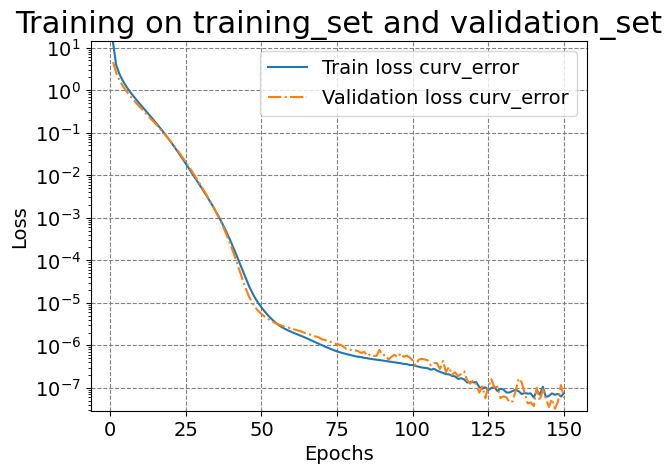

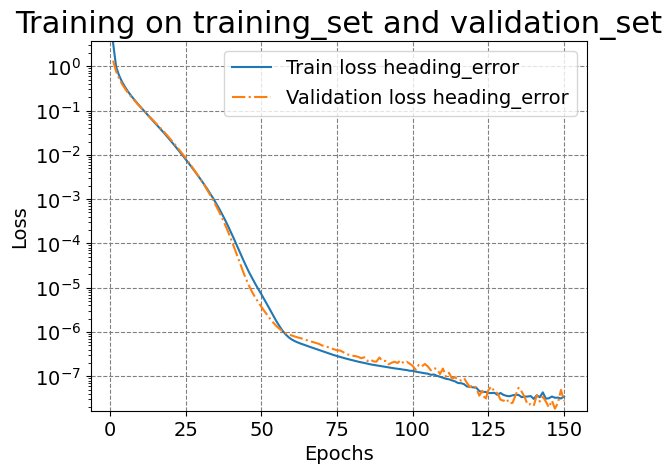

Selected the model at the epoch 147.


In [8]:
# First training without samples in the future
lat_dyna_model.trainModel(training_params=training_pars)

======================== nnodely Model Train Parameters ========================
models:                       ['vehicle_model']
num of epochs:                20
update per epochs:            185
└>len(train_indexes)//(batch_size+step)
shuffle data:                 True
early stopping:               early_stop_patience
early stopping params:        {'error': 'curv_error', 'patience': 20}
prediction samples:           80
step:                         0
closed loop:                  {}
connect:                      {}
train dataset:                training_set
	- batch size:                64
	- num of samples:            12212
	- num of first samples:      11892
validation dataset:           validation_set
	- batch size:                64
	- num of samples:            5616
	- num of first samples:      5456
minimizers:                   {'curv_error': {'A': 'SamplePart95',
                                              'B': 'Mul72',
                                              'loss': '

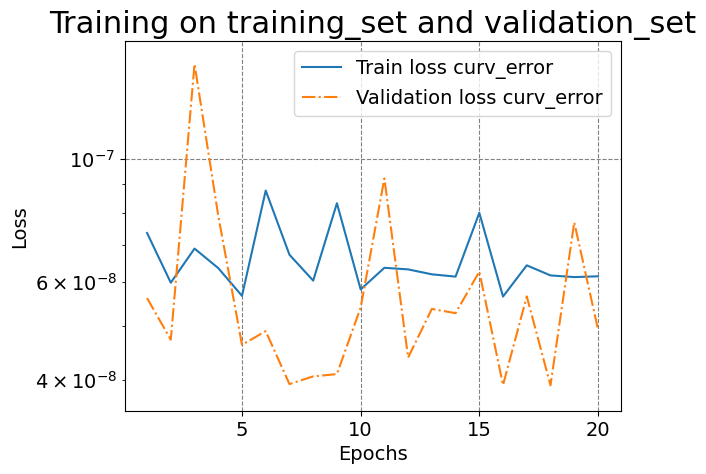

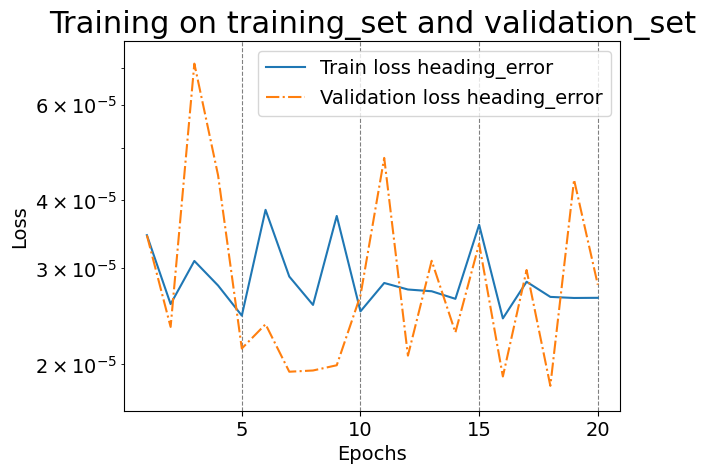

Selected the model at the epoch 18.


In [9]:
# Training with intergal error 4s in the future
lat_dyna_model.trainModel(
    training_params=training_pars, num_of_epochs=20, prediction_samples=80
)

# Results Analysis

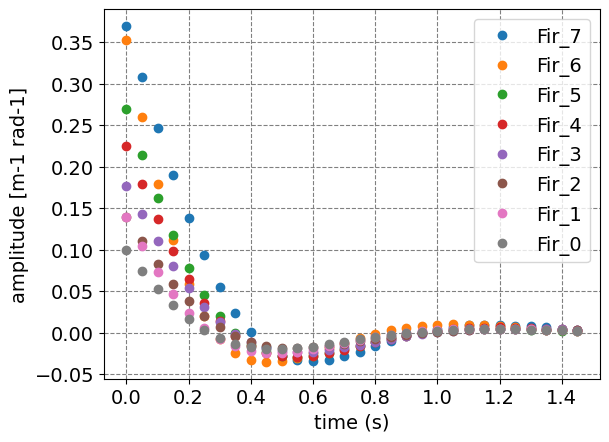

In [10]:
# Analysis of the FIR parameters
params_fir = {}
sampling_time = 0.05

# Plot
plt.figure()

for key, value in lat_dyna_model.parameters.items():
    if key.startswith("Fir_"):
        params_fir[key] = lat_dyna_model.parameters[key]

for key, value in params_fir.items():
    vals = np.array(value).flatten()
    t = np.arange(0, sampling_time * len(vals), sampling_time)
    plt.plot(t, np.flip(vals * W_fir.flatten()), "o", label=key)
t = np.arange(0, sampling_time * samples_past_steer, sampling_time)
plt.xlabel("time (s)")
plt.ylabel("amplitude [m-1 rad-1]")
plt.legend()
plt.grid(True)
plt.show()

### Test set: curvature comparison

============================ nnodely Model Dataset =============================
Dataset Name:                 test_set
Number of files:              1
Total number of samples:      1075
Shape of model_vx_in:         (1075, 2, 1)
Shape of model_ax_in:         (1075, 1, 1)
Shape of model_steer_in:      (1075, 30, 1)
Shape of model_curv_in:       (1075, 1, 1)
[__call__] Different number of samples between inputs [MAX 1000 = 1000; MIN 0 = 0]


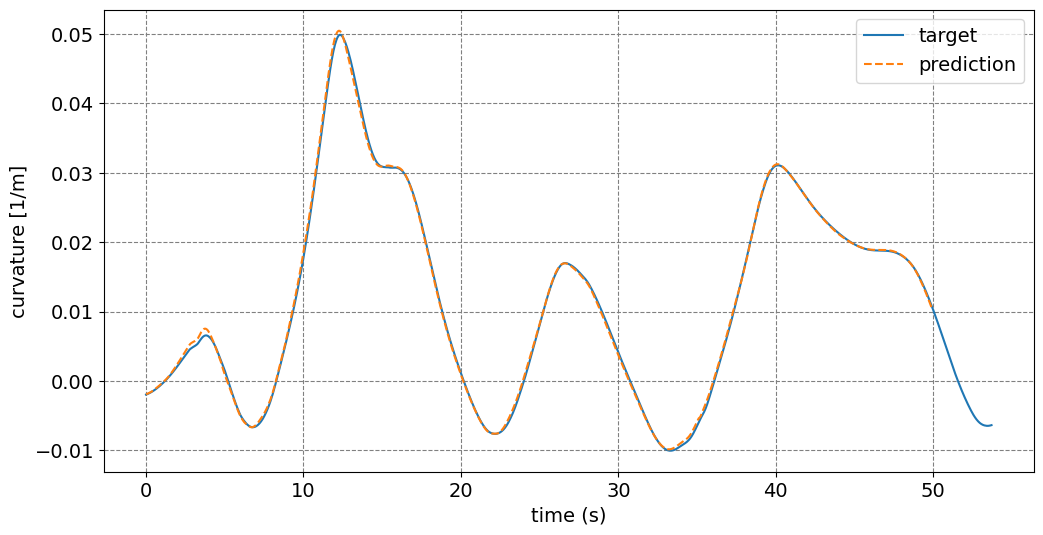

In [11]:
# Dataset extraction
lat_dyna_model.loadData(
    "test_set",
    source="dataset/test",
    format=["", "model_ax_in", "", "model_vx_in", "model_curv_in", "model_steer_in"],
    skiplines=1,
)
data_in = lat_dyna_model.getSamples("test_set", index=1, window=1000)

# Model inference
out_nn = lat_dyna_model(data_in, sampled=True)

dataset = pd.read_csv("dataset/test/test_set.csv")

# Plot
plt.figure(figsize=(12, 6))
plt.plot(
    0.05 * np.arange(len(np.array(dataset["curv"])[30:])),
    np.array(dataset["curv"])[30:],
    label="target",
)
plt.plot(
    0.05 * np.arange(len(out_nn["model_curv"])),
    out_nn["model_curv"],
    "--",
    label="prediction",
)
plt.xlabel("time (s)")
plt.ylabel("curvature [1/m]")
plt.grid(True)
plt.legend()
plt.show()

# SAVE MODEL

In [12]:
# Save json model: will be used in the controller training
lat_dyna_model.saveModel("vehicle_model")

=============================== Save JSON Model ================================
Model saved in:               trained_models/vehicle_model.json
